# Prediksi Loan Status menggunakan SVR

Notebook ini melakukan prediksi **Loan_Status** menggunakan algoritma **SVR (Support Vector Regression)** dengan threshold 0.5 untuk klasifikasi biner.

Dataset yang digunakan berasal dari 4 jenis transformasi:
- **Z-Score** (df_zscore, df_zscore_drop, df_zscore_replace)
- **Log Transform** (df_log, df_log_drop, df_log_replace)
- **MinMax Scaling** (df_minmax, df_minmax_drop, df_minmax_replace)
- **Decimal Scaling** (df_decimal, df_decimal_drop, df_decimal_replace)

Setiap dataset dievaluasi menggunakan **F1 Score, Precision, dan Recall**.

## 1. Import Library

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

print('Libraries imported successfully!')

Libraries imported successfully!


In [54]:
import preprocessing2
print(preprocessing2.__file__)  # liat dia load dari mana

/media/pratama/Data/Other/SELURUH FILE PERKULIAHAN/MATERI SMESTER 6/Data Mining/Projek/projek1/syntax/preprocessing2.py


In [55]:
import traceback
try:
    import importlib
    import preprocessing2
    importlib.reload(preprocessing2)
except Exception as e:
    traceback.print_exc()

## 2. Import Dataset dari preprocessing2

In [56]:
from preprocessing2 import (
    # Z-Score
    df_zscore,
    df_zscore_drop,
    df_zscore_replace,

    # Log Transform
    df_log,
    df_log_drop,
    df_log_replace,

    # MinMax
    df_minmax,
    df_minmax_drop,
    df_minmax_replace,

    # Decimal Scaling
    df_decimal,
    df_decimal_drop,
    df_decimal_replace,
)

print('Semua dataset berhasil diimport!')

Semua dataset berhasil diimport!


## 3. Definisi Fungsi SVR + Evaluasi

Fungsi berikut:
1. Memisahkan fitur (X) dan target (y = Loan_Status)
2. Drop kolom non-numerik (Loan_ID)
3. Split train/test 80/20
4. Training SVR dengan kernel RBF
5. Prediksi → threshold 0.5 → konversi ke label 0/1
6. Mengembalikan semua metrik evaluasi

In [57]:
def run_svr(df, dataset_name, test_size=0.2, random_state=42):
    """
    Melatih SVR pada dataset dan mengembalikan hasil evaluasi.

    Parameters:
        df           : DataFrame yang sudah di-encode dan di-transform
        dataset_name : Nama dataset (untuk label di output)
        test_size    : Proporsi data test (default 0.2 = 20%)
        random_state : Random seed

    Returns:
        dict berisi semua metrik evaluasi
    """
    df_clean = df.copy()

    # Drop kolom non-numerik (Loan_ID)
    if 'Loan_ID' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Loan_ID'])

    # Pisah fitur dan target
    X = df_clean.drop(columns=['Loan_Status'])
    y = df_clean['Loan_Status']

    # Split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Training SVR
    svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    svr.fit(X_train, y_train)

    # Prediksi → threshold 0.5
    y_pred_raw  = svr.predict(X_test)
    y_pred      = (y_pred_raw >= 0.5).astype(int)

    # Metrik
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    cm        = confusion_matrix(y_test, y_pred)

    return {
        'Dataset'   : dataset_name,
        'Accuracy'  : round(acc, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1 Score'  : round(f1, 4),
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'cm'        : cm,
        'model'     : svr,
        'X_train'   : X_train,
        'X_test'    : X_test,
        'columns'   : X.columns.tolist(),
    }

print('Fungsi SVR siap digunakan!')

Fungsi SVR siap digunakan!


## 4. Training & Evaluasi Semua Dataset

Menjalankan SVR pada seluruh 12 dataset transformasi.

In [58]:
datasets = {
    # Z-Score
    'ZScore (Original)'  : df_zscore,
    'ZScore (Drop)'      : df_zscore_drop,
    'ZScore (Replace)'   : df_zscore_replace,

    # Log Transform
    'Log (Original)'     : df_log,
    'Log (Drop)'         : df_log_drop,
    'Log (Replace)'      : df_log_replace,

    # MinMax
    'MinMax (Original)'  : df_minmax,
    'MinMax (Drop)'      : df_minmax_drop,
    'MinMax (Replace)'   : df_minmax_replace,

    # Decimal Scaling
    'Decimal (Original)' : df_decimal,
    'Decimal (Drop)'     : df_decimal_drop,
    'Decimal (Replace)'  : df_decimal_replace,
}

results = {}
for name, df_data in datasets.items():
    print(f'Training SVR: {name} ...')
    results[name] = run_svr(df_data, name)

print('\nSemua model selesai ditraining!')

Training SVR: ZScore (Original) ...
Training SVR: ZScore (Drop) ...
Training SVR: ZScore (Replace) ...
Training SVR: Log (Original) ...
Training SVR: Log (Drop) ...
Training SVR: Log (Replace) ...
Training SVR: MinMax (Original) ...
Training SVR: MinMax (Drop) ...
Training SVR: MinMax (Replace) ...
Training SVR: Decimal (Original) ...
Training SVR: Decimal (Drop) ...
Training SVR: Decimal (Replace) ...

Semua model selesai ditraining!


## 5. Tabel Perbandingan Hasil Evaluasi

Rangkuman **Accuracy, Precision, Recall, dan F1 Score** dari semua 12 dataset.

In [59]:
summary = pd.DataFrame([
    {
        'Dataset'   : r['Dataset'],
        'Accuracy'  : r['Accuracy'],
        'Precision' : r['Precision'],
        'Recall'    : r['Recall'],
        'F1 Score'  : r['F1 Score'],
    }
    for r in results.values()
])

summary = summary.sort_values('F1 Score', ascending=False).reset_index(drop=True)

# Highlight nilai terbaik
summary.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    color='lightgreen'
).highlight_min(
    subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    color='#ffcccc'
)

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Decimal (Drop),0.862700,0.841500,0.985700,0.907900
1,MinMax (Drop),0.862700,0.841500,0.985700,0.907900
2,MinMax (Original),0.853700,0.831700,0.988200,0.903200
3,MinMax (Replace),0.853700,0.831700,0.988200,0.903200
4,Decimal (Original),0.853700,0.831700,0.988200,0.903200
5,Decimal (Replace),0.853700,0.831700,0.988200,0.903200
6,ZScore (Drop),0.852900,0.839500,0.971400,0.900700
7,ZScore (Original),0.837400,0.828300,0.964700,0.891300
8,ZScore (Replace),0.837400,0.828300,0.964700,0.891300
9,Log (Original),0.691100,0.691100,1.000000,0.817300


## 6. Visualisasi Perbandingan Metrik

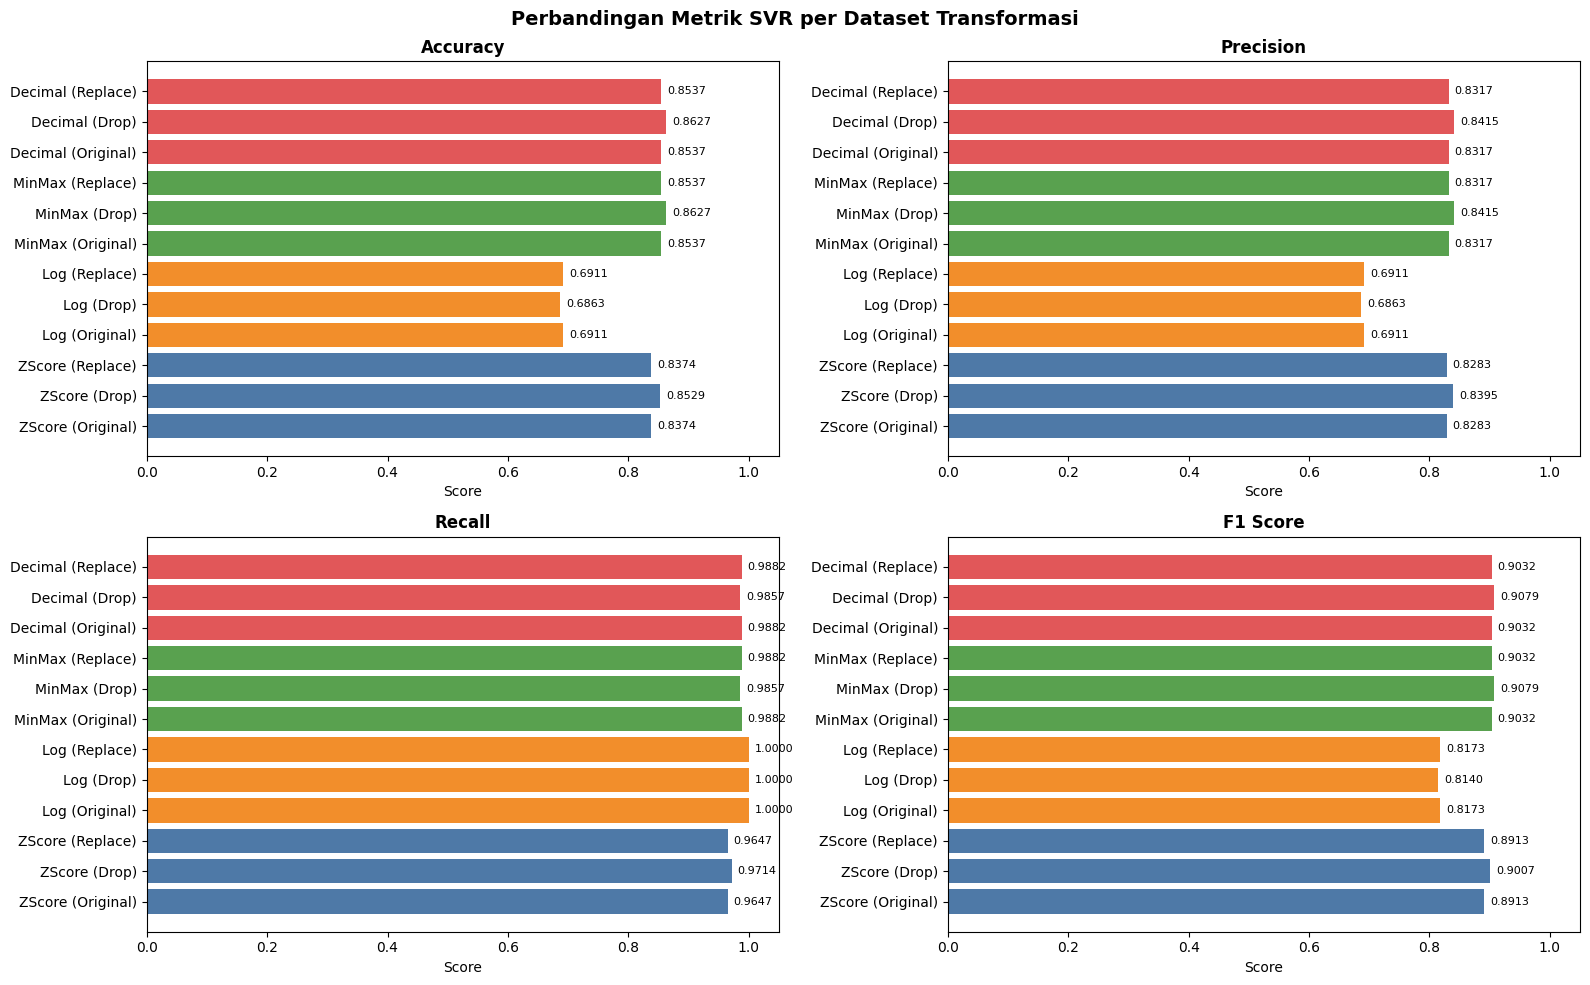

In [60]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Metrik SVR per Dataset Transformasi', fontsize=14, fontweight='bold')

colors = [
    '#4e79a7', '#4e79a7', '#4e79a7',  # ZScore - biru
    '#f28e2b', '#f28e2b', '#f28e2b',  # Log - oranye
    '#59a14f', '#59a14f', '#59a14f',  # MinMax - hijau
    '#e15759', '#e15759', '#e15759',  # Decimal - merah
]

for ax, metric in zip(axes.flatten(), metrics):
    vals = [results[name][metric] for name in datasets.keys()]
    bars = ax.barh(list(datasets.keys()), vals, color=colors)
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix Semua Dataset

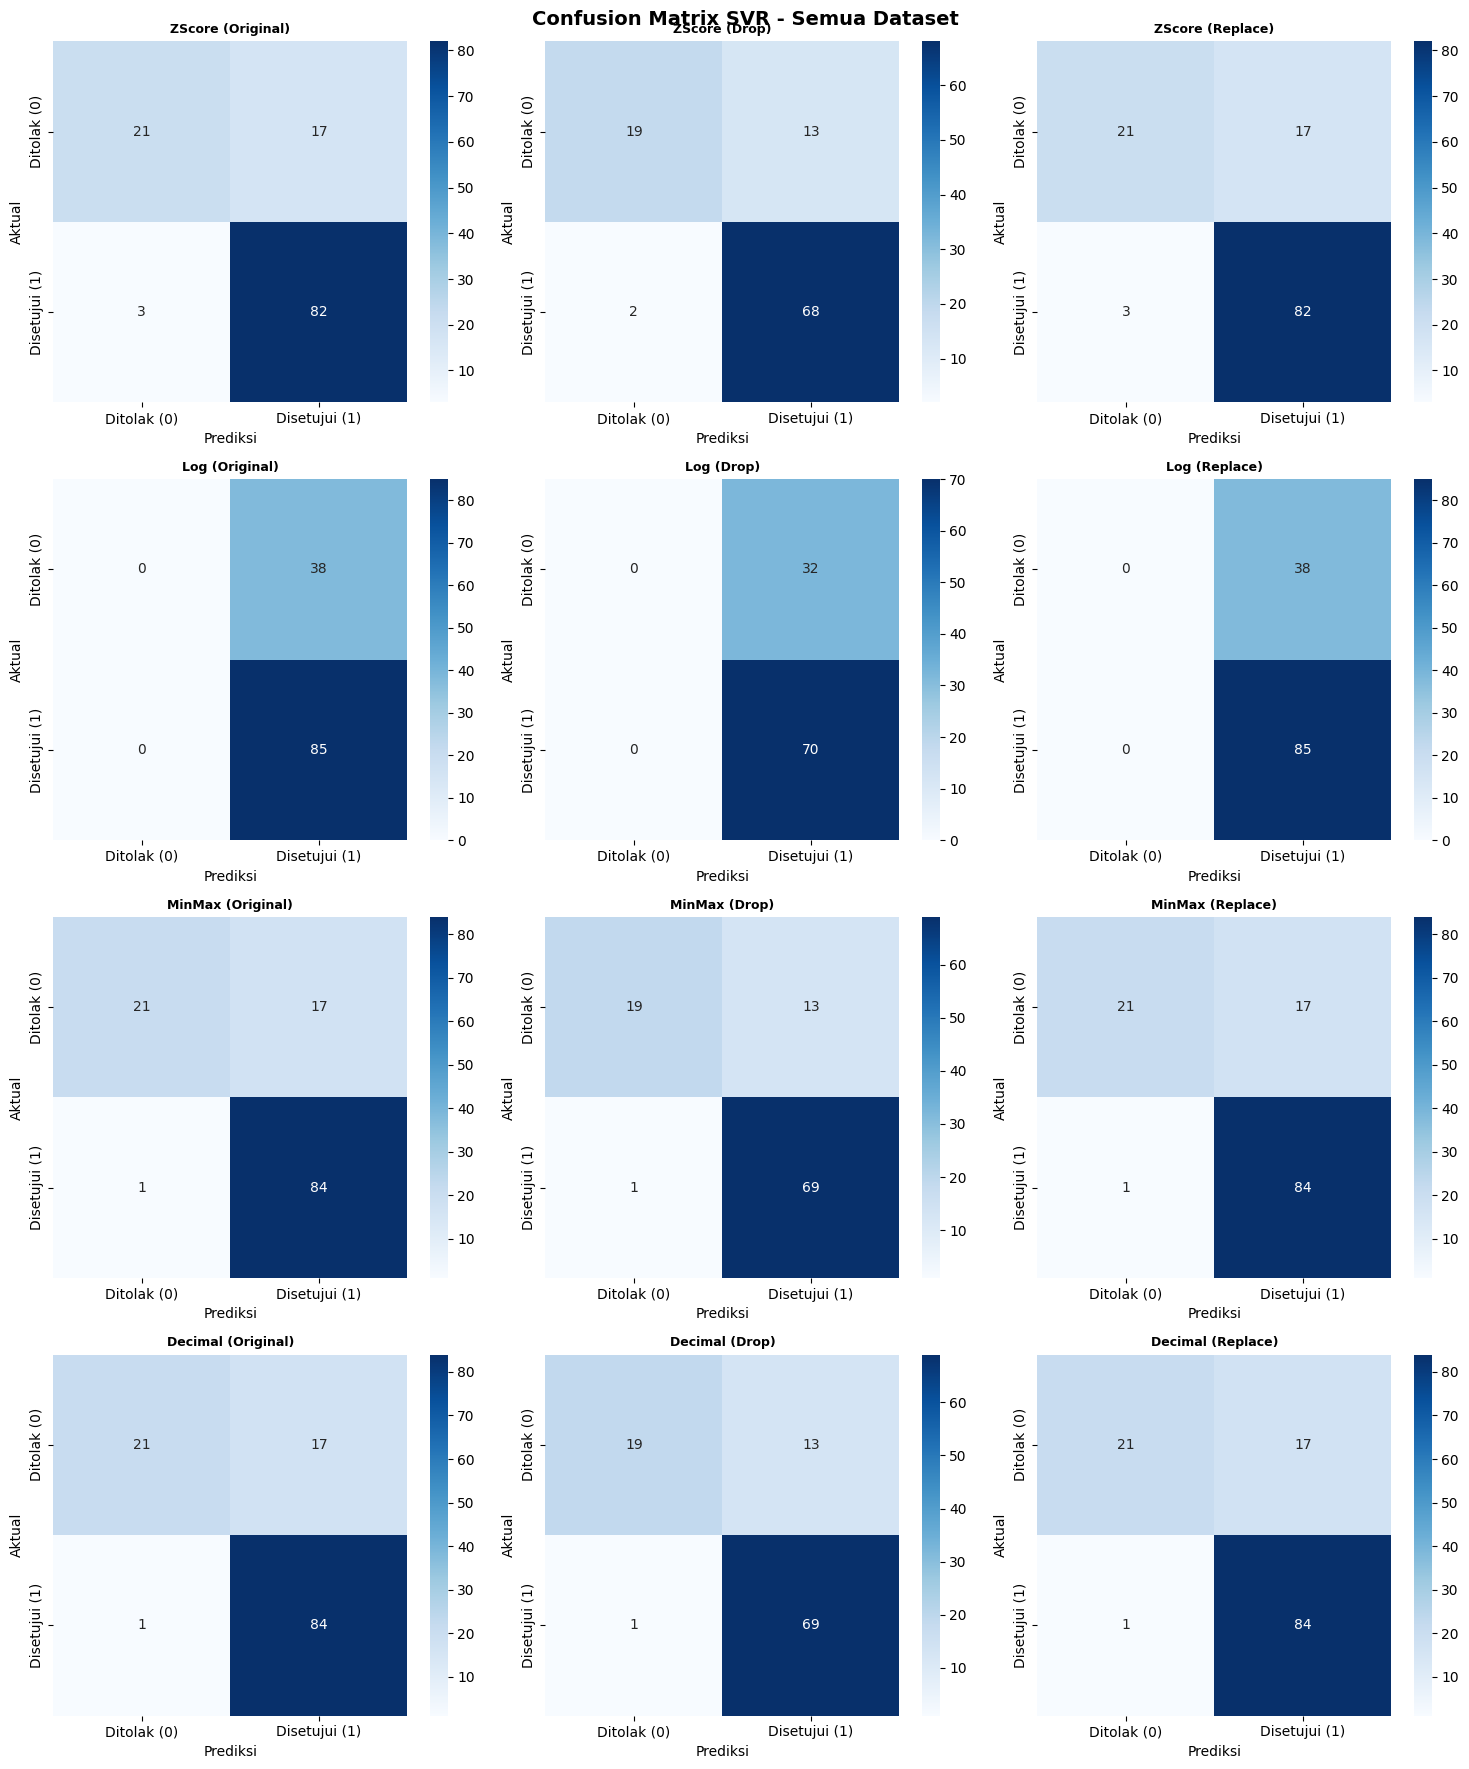

In [61]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.suptitle('Confusion Matrix SVR - Semua Dataset', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ditolak (0)', 'Disetujui (1)'],
        yticklabels=['Ditolak (0)', 'Disetujui (1)'],
        ax=ax
    )
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

## 8. Classification Report Detail per Dataset

In [62]:
for name, res in results.items():
    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(
        res['y_test'], res['y_pred'],
        target_names=['Ditolak (0)', 'Disetujui (1)'],
        zero_division=0
    ))
    print()

  ZScore (Original)
               precision    recall  f1-score   support

  Ditolak (0)       0.88      0.55      0.68        38
Disetujui (1)       0.83      0.96      0.89        85

     accuracy                           0.84       123
    macro avg       0.85      0.76      0.78       123
 weighted avg       0.84      0.84      0.83       123


  ZScore (Drop)
               precision    recall  f1-score   support

  Ditolak (0)       0.90      0.59      0.72        32
Disetujui (1)       0.84      0.97      0.90        70

     accuracy                           0.85       102
    macro avg       0.87      0.78      0.81       102
 weighted avg       0.86      0.85      0.84       102


  ZScore (Replace)
               precision    recall  f1-score   support

  Ditolak (0)       0.88      0.55      0.68        38
Disetujui (1)       0.83      0.96      0.89        85

     accuracy                           0.84       123
    macro avg       0.85      0.76      0.78       123


## 9. Pengujian dengan Data Baru

Pengujian dilakukan pada **setiap model** (12 model) menggunakan satu sampel data baru.

> **Catatan:** Nilai data baru di bawah sudah dalam bentuk yang sesuai dengan transformasi masing-masing. Sesuaikan nilai input jika kamu ingin mencoba data lain.

In [63]:
# ── Data baru (raw, belum ditransformasi) ──────────────────────────
# Sesuaikan isi ini dengan data baru yang ingin diprediksi
new_data_raw = {
    'Gender'            : 1,      # 1=Male, 0=Female
    'Married'           : 1,      # 1=Yes, 0=No
    'Dependents'        : 3,    # 0, 1, 2, 3
    'Education'         : 0,      # 1=Graduate, 0=Not Graduate
    'Self_Employed'     : 0,      # 1=Yes, 0=No
    'ApplicantIncome'   : 1000,
    'CoapplicantIncome' : 1000,
    'LoanAmount'        : 150,
    'Loan_Amount_Term'  : 360,
    'Credit_History'    : 0.0,
    'Property_Area'     : 2,      # 1=Urban, 2=Rural, 3=Semiurban
    'Total_Income'      : 2000,   # ApplicantIncome + CoapplicantIncome
}

new_df = pd.DataFrame([new_data_raw])
print('Data baru yang akan diprediksi:')
print(new_df.T)

Data baru yang akan diprediksi:
                        0
Gender                1.0
Married               1.0
Dependents            3.0
Education             0.0
Self_Employed         0.0
ApplicantIncome    1000.0
CoapplicantIncome  1000.0
LoanAmount          150.0
Loan_Amount_Term    360.0
Credit_History        0.0
Property_Area         2.0
Total_Income       2000.0


In [64]:
print('\n' + '='*55)
print('  HASIL PREDIKSI DATA BARU - SEMUA MODEL')
print('='*55)

new_predictions = []

for name, res in results.items():
    model   = res['model']
    cols    = res['columns']

    # Pastikan kolom input sesuai urutan training
    input_data = new_df[cols] if all(c in new_df.columns for c in cols) else None

    if input_data is None:
        print(f'{name:30s} : Kolom tidak lengkap, skip')
        continue

    pred_raw = model.predict(input_data)[0]
    pred_label = 1 if pred_raw >= 0.5 else 0
    status = 'DISETUJUI ✅' if pred_label == 1 else 'DITOLAK ❌'

    print(f'{name:30s} : {status}  (raw={pred_raw:.4f})')
    new_predictions.append({
        'Dataset'    : name,
        'Raw Score'  : round(pred_raw, 4),
        'Prediksi'   : pred_label,
        'Status'     : 'Disetujui' if pred_label == 1 else 'Ditolak'
    })

print('='*55)
pred_df = pd.DataFrame(new_predictions)
print(f"\nRingkasan: {(pred_df['Prediksi']==1).sum()} model prediksi DISETUJUI, "
      f"{(pred_df['Prediksi']==0).sum()} model prediksi DITOLAK")


  HASIL PREDIKSI DATA BARU - SEMUA MODEL
ZScore (Original)              : DISETUJUI ✅  (raw=0.5909)
ZScore (Drop)                  : DISETUJUI ✅  (raw=0.5123)
ZScore (Replace)               : DISETUJUI ✅  (raw=0.5396)
Log (Original)                 : DISETUJUI ✅  (raw=0.8291)
Log (Drop)                     : DISETUJUI ✅  (raw=0.8175)
Log (Replace)                  : DISETUJUI ✅  (raw=0.8324)
MinMax (Original)              : DISETUJUI ✅  (raw=0.5471)
MinMax (Drop)                  : DISETUJUI ✅  (raw=0.5432)
MinMax (Replace)               : DISETUJUI ✅  (raw=0.5921)
Decimal (Original)             : DISETUJUI ✅  (raw=0.6595)
Decimal (Drop)                 : DISETUJUI ✅  (raw=0.6183)
Decimal (Replace)              : DISETUJUI ✅  (raw=0.6506)

Ringkasan: 12 model prediksi DISETUJUI, 0 model prediksi DITOLAK


## 10. Ringkasan Akhir & Rekomendasi Model Terbaik

In [65]:
print('RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)')
print('='*65)
print(summary.to_string(index=False))

best = summary.iloc[0]
worst = summary.iloc[-1]

print(f'\n🏆 Model TERBAIK  : {best["Dataset"]}')
print(f'   F1={best["F1 Score"]:.4f} | Precision={best["Precision"]:.4f} | Recall={best["Recall"]:.4f} | Accuracy={best["Accuracy"]:.4f}')

print(f'\n⚠️  Model TERENDAH : {worst["Dataset"]}')
print(f'   F1={worst["F1 Score"]:.4f} | Precision={worst["Precision"]:.4f} | Recall={worst["Recall"]:.4f} | Accuracy={worst["Accuracy"]:.4f}')

RANGKUMAN PERFORMA MODEL (diurutkan F1 Score)
           Dataset  Accuracy  Precision  Recall  F1 Score
    Decimal (Drop)    0.8627     0.8415  0.9857    0.9079
     MinMax (Drop)    0.8627     0.8415  0.9857    0.9079
 MinMax (Original)    0.8537     0.8317  0.9882    0.9032
  MinMax (Replace)    0.8537     0.8317  0.9882    0.9032
Decimal (Original)    0.8537     0.8317  0.9882    0.9032
 Decimal (Replace)    0.8537     0.8317  0.9882    0.9032
     ZScore (Drop)    0.8529     0.8395  0.9714    0.9007
 ZScore (Original)    0.8374     0.8283  0.9647    0.8913
  ZScore (Replace)    0.8374     0.8283  0.9647    0.8913
    Log (Original)    0.6911     0.6911  1.0000    0.8173
     Log (Replace)    0.6911     0.6911  1.0000    0.8173
        Log (Drop)    0.6863     0.6863  1.0000    0.8140

🏆 Model TERBAIK  : Decimal (Drop)
   F1=0.9079 | Precision=0.8415 | Recall=0.9857 | Accuracy=0.8627

⚠️  Model TERENDAH : Log (Drop)
   F1=0.8140 | Precision=0.6863 | Recall=1.0000 | Accuracy=0.6863
